### Initialization

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np

input_shape = 200
# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

2025-09-17 23:09:00.360370: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-17 23:09:00.389128: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-17 23:09:00.975616: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Get data

In [3]:
import tensorflow as tf
import os
import glob
from sklearn.model_selection import train_test_split

IMAGES_UNLABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/d_aug"
IMAGES_LABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/test_v2_aug"
INPUT_SHAPE = 200
BATCH_SIZE = 64

def load_and_preprocess_image(path):
    """Loads and preprocesses a single image, ignoring labels."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_unlabeled_dataset(file_list, batch_size):
    """Creates a tf.data.Dataset for unlabeled images."""
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [4]:
# Get all unlabeled image paths
unlabeled_files = glob.glob(os.path.join(IMAGES_UNLABELED_PATH, '*'))

# Get all labeled image paths (from all subdirectories)
labeled_files = glob.glob(os.path.join(IMAGES_LABELED_PATH, '*/*'))

# --- THIS IS THE KEY STEP ---
# Combine them into a single list for M1 training
all_files = unlabeled_files + labeled_files
print(f"Total images for M1 training: {len(all_files)}")

# Split the combined list for training and validation
m1_train_files, m1_val_files = train_test_split(all_files, test_size=0.2, random_state=42)
print(f"M1 training set size: {len(m1_train_files)}")
print(f"M1 validation set size: {len(m1_val_files)}")

Total images for M1 training: 10171
M1 training set size: 8136
M1 validation set size: 2035


### Definition of the encoder

In [5]:
# A custom layer to sample from the latent space
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LeakyReLU, BatchNormalization, Cropping2D

def build_encoder(latent_dim):
    """Builds a deeper encoder for 200x200 images."""
    inputs = layers.Input(shape=(200, 200, 1))
    
    # Downsampling from 200x200 -> 100x100
    x = layers.Conv2D(32, 5, strides=2, padding='same')(inputs)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    # 100x100 -> 50x50
    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    # 50x50 -> 25x25
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 25x25 -> 13x13 (approx)
    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 13x13 -> 7x7
    # x = layers.Conv2D(256, 3, strides=1, padding='same')(x)
    # x = LeakyReLU(negative_slope=0.2)(x)
    # x = BatchNormalization()(x)

    # We'll stop downsampling here at a 13x13 feature map
    # Note: 200 -> 100 -> 50 -> 25 -> 13 (due to 'same' padding)
    
    # Fully Connected Head
    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    # x = layers.Dropout(0.2)(x) # Rate of 0.5 is a common starting point

    # Latent space
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var]) # Assumes Sampling layer is defined
    
    encoder = models.Model(inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

### Definition of decoder

In [7]:
def build_decoder(latent_dim):
    """Builds a deeper decoder for 200x200 images."""
    latent_inputs = layers.Input(shape=(latent_dim,))
    
    # Prepare for upsampling
    x = layers.Dense(256)(latent_inputs)
    x = LeakyReLU(negative_slope=0.2)(x)
    # The shape corresponds to the encoder's output before flattening
    x = layers.Dense(13 * 13 * 256)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((13, 13, 256))(x)

    # Upsampling from 7x7 -> 14x14
    # x = layers.Conv2DTranspose(512, 3, strides=2, padding='same')(x)
    # x = LeakyReLU(negative_slope=0.2)(x)
    # x = BatchNormalization()(x)

    # Upsampling from 14x14 -> 28x28
    x = layers.Conv2DTranspose(256, 3, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    # 28x28 -> 56x56
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    # 56x56 -> 112x112
    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    # 112x112 -> 224x224
    x = layers.Conv2DTranspose(32, 5, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)
    
    x = layers.Cropping2D(((4,4),(4,4)))(x)

    # Final output layer
    outputs = layers.Conv2DTranspose(1, 5, activation='sigmoid', padding='same')(x)
    
    decoder = models.Model(latent_inputs, outputs, name="decoder")
    return decoder

### Definition of the VAE

#### Losses

In [8]:
# Mean Squared Error will be our comparison metric
mse_loss = tf.keras.losses.MeanSquaredError()

# Load the VGG19 model to be used as our feature extractor
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

# Select the intermediate layers whose outputs we'll use for the loss
layer_names = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
]
# Create a new model that outputs the feature maps from these selected layers
vgg_feature_extractor = tf.keras.Model(inputs=vgg.input, outputs=[vgg.get_layer(name).output for name in layer_names])

def perceptual_loss(y_true, y_pred):
    # Ensure images are in the float32 [0, 1] range
    y_true = tf.convert_to_tensor(y_true, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    # Convert grayscale images to 3-channel RGB for VGG19
    y_true_rgb = tf.image.grayscale_to_rgb(y_true)
    y_pred_rgb = tf.image.grayscale_to_rgb(y_pred)
    
    # The VGG network expects its inputs to be preprocessed in a specific way
    y_true_processed = tf.keras.applications.vgg19.preprocess_input(y_true_rgb * 255.0)
    y_pred_processed = tf.keras.applications.vgg19.preprocess_input(y_pred_rgb * 255.0)
    
    # Get the feature maps from the VGG model
    true_features = vgg_feature_extractor(y_true_processed)
    pred_features = vgg_feature_extractor(y_pred_processed)
    
    # Calculate the loss by comparing the feature maps
    total_loss = 0.0
    for true_feat, pred_feat in zip(true_features, pred_features):
        total_loss += mse_loss(true_feat, pred_feat)
        
    return total_loss

class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim

I0000 00:00:1758161341.682888   89797 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13018 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


#### VAE Model

In [9]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, reconstruction_loss_fn, beta, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta#tf.Variable(0.0, trainable=False, name='kl_beta_weight')
        self.recon_loss_fn = reconstruction_loss_fn #MeanSquaredError()

    def call(self, inputs):
        """Defines the forward pass of the VAE."""
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def _calculate_loss(self, data):
        """Helper function to calculate all VAE loss components."""
        if isinstance(data, tuple):
            data = data[0]
        
        reconstruction = self(data)
        z_mean, z_log_var, _ = self.encoder(data)
        
        # Binary Crossentropy Reconstruction Loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2),
            )
        )

        # SSIM Reconstruction Loss
        # reconstruction_loss = self.recon_loss_fn(data, reconstruction)
        # reconstruction_loss = reconstruction_loss * (input_shape * input_shape)

        # Perceptual Loss
        # reconstruction_loss = perceptual_loss(data, reconstruction)

        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        
        total_loss = reconstruction_loss +  self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        """Defines the logic for one training step."""
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # We manually log our losses, so this is all that's needed.
        return {
            "loss": total_loss, # 'loss' is the primary monitored metric
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
            "beta": self.beta
        }

    def test_step(self, data):
        """Defines the logic for one validation step."""
        total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)
        
        # We manually log our losses here as well.
        return {
            "loss": total_loss, # 'loss' is the primary monitored metric
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

### Training

#### Callbacks definition

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import clear_output

class LiveImageGenerator(tf.keras.callbacks.Callback):
    def __init__(self, num_images, latent_dim):
        super().__init__()
        self.num_images = num_images
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # Generate random latent vectors
        random_latent_vectors = tf.random.normal(
            shape=(self.num_images, self.latent_dim)
        )

        # Use the decoder to generate images
        generated_images = self.model.decoder.predict(random_latent_vectors, verbose=0)
        
        # Create a plot grid
        grid_size = int(np.sqrt(self.num_images))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))
        fig.suptitle(f'Generated Images at Epoch {epoch + 1}', fontsize=12)
        
        for i, ax in enumerate(axes.flat):
            # --- THIS IS THE CHANGE ---
            # .squeeze() removes the channel dimension, and cmap='gray' sets the colormap.
            ax.imshow(generated_images[i].squeeze(), cmap='gray')
            ax.axis("off")
            
        # Clear the previous output and display the new plot
        clear_output(wait=True)
        plt.show()

class KLAnnealingCallback(tf.keras.callbacks.Callback):
    def __init__(self, anneal_duration_steps, kl_end_weight=0.5, kl_start_weight=0.0):
        super().__init__()
        self.anneal_duration = float(anneal_duration_steps)
        self.kl_start = float(kl_start_weight)
        self.kl_end = float(kl_end_weight)
        self.step = 0.0

    def on_train_batch_begin(self, batch, logs=None):
        # This method is called at the start of every training batch
        self.step += 1
        
        # Calculate the new beta value using a linear schedule
        ratio = min(1.0, self.step / self.anneal_duration)
        new_beta = self.kl_start + (self.kl_end - self.kl_start) * ratio
        
        # Update the beta value inside the VAE model
        self.model.beta.assign(new_beta)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',      # The metric to monitor
    patience=7,             # Number of epochs to wait for improvement
    verbose=1,               # Print a message when stopping
    restore_best_weights=True # Restore weights from the best epoch
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',   # The metric to monitor
    factor=0.2,           # Factor by which to reduce the learning rate (new_lr = lr * factor)
    patience=7,           # Number of epochs to wait for improvement
    verbose=1,            # Print a message when the LR is updated
    min_lr=1e-6           # The minimum learning rate
)

#### VAE training

In [12]:
from tensorflow.keras.losses import MeanSquaredError # <-- Import the class

# Create the datasets for M1 training and validation
latent_dim = 8
epochs = 30
beta = 0.5

# --- 1. Define your hyperparameters ---
NUM_SAMPLES_TO_GENERATE = 16 # e.g., for a 4x4 grid

# --- 2. Instantiate the callback ---
live_image_callback = LiveImageGenerator(
    num_images=NUM_SAMPLES_TO_GENERATE,
    latent_dim=latent_dim
)

steps_per_epoch = len(m1_train_files) // BATCH_SIZE 
annealing_duration = 10 * steps_per_epoch
kl_annealing_callback = KLAnnealingCallback(kl_end_weight=beta, anneal_duration_steps=annealing_duration)

m1_train_dataset = make_unlabeled_dataset(m1_train_files, BATCH_SIZE)
m1_val_dataset = make_unlabeled_dataset(m1_val_files, BATCH_SIZE)


# --- 1. Instantiate the VAE model ---
# Note: we pass an initial_beta of 0.0
encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)
# custom_recon_loss = CustomLoss(y=0.17, z=0.83)
custom_recon_loss = MeanSquaredError()
vae = VAE(encoder, decoder, reconstruction_loss_fn=custom_recon_loss, beta=beta)

# --- 2. Compile the model ---
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

# Add the new callback to the list
callbacks = [early_stopping, lr_scheduler, live_image_callback]#, kl_annealing_callback]

# --- 4. Train the model ---
print("Training the VAE (M1 model) with beta annealing...")
history = vae.fit(
    m1_train_dataset,
    epochs=epochs,
    validation_data=m1_val_dataset,
    callbacks=callbacks
)

print("Training complete!")

Training the VAE (M1 model) with beta annealing...
Epoch 1/30


KeyboardInterrupt: 

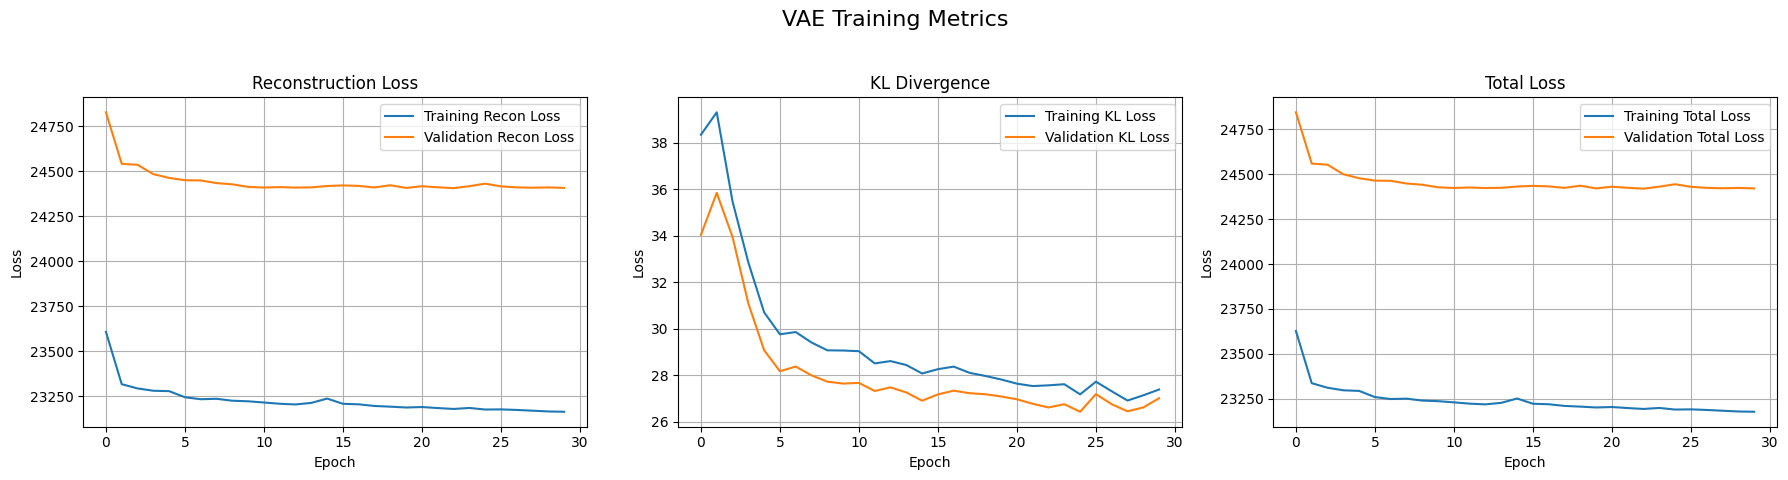

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the history object for easier plotting
history_df = pd.DataFrame(history.history)

# Create a figure with three subplots arranged in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VAE Training Metrics', fontsize=16)

# --- Plot 1: Reconstruction Loss ---
axes[0].plot(history_df['reconstruction_loss'], label='Training Recon Loss')
axes[0].plot(history_df['val_reconstruction_loss'], label='Validation Recon Loss')
axes[0].set_title('Reconstruction Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: KL Loss ---
axes[1].plot(history_df['kl_loss'], label='Training KL Loss')
axes[1].plot(history_df['val_kl_loss'], label='Validation KL Loss')
axes[1].set_title('KL Divergence')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Total Loss ---
axes[2].plot(history_df['loss'], label='Training Total Loss')
axes[2].plot(history_df['val_loss'], label='Validation Total Loss')
axes[2].set_title('Total Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Generate random images

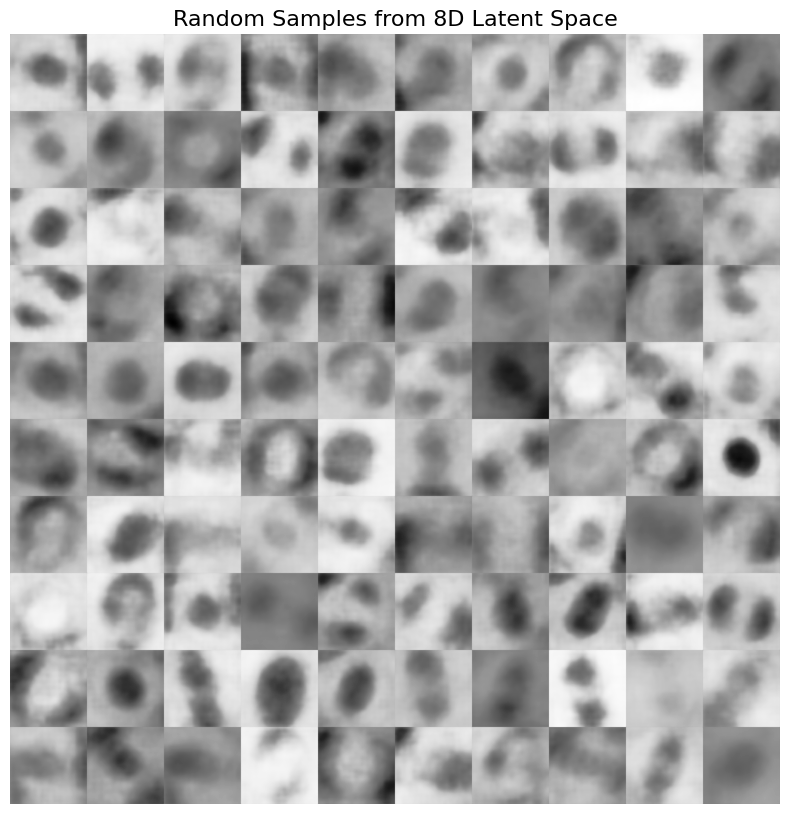

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_randomly_generated_images(decoder, latent_dim, n=10, figsize=10):
    """
    Plots a grid of randomly generated digits for any latent dimension.
    """
    # Create a figure to display the images
    figure = np.zeros((input_shape * n, input_shape * n))
    
    # Iterate over the grid positions
    for i in range(n):
        for j in range(n):
            # Generate a random latent vector from a normal distribution
            z_sample = np.random.normal(size=(1, latent_dim))
            
            # Decode the latent vector to generate an image
            x_decoded = decoder.predict(z_sample, verbose=0)
            
            # Reshape the output to a 28x28 image
            digit = x_decoded[0].reshape(input_shape, input_shape)
            
            # Place the digit into our display figure
            figure[i * input_shape : (i + 1) * input_shape,
                   j * input_shape : (j + 1) * input_shape] = digit

    # Plot the final figure
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="Greys_r")
    plt.axis('off')
    plt.title(f"Random Samples from {latent_dim}D Latent Space", fontsize=16)
    plt.show()

# --- HOW TO USE ---
# Call the new function with your deeper decoder and its latent dimension
plot_randomly_generated_images(decoder, latent_dim)

### Plot unlabeled latent space

In [ ]:
import numpy as np

# 1. Run the encoder on the entire test_dataset to get the latent vectors
print("Generating latent vectors for the custom test set...")
z_mean, _, _ = encoder.predict(m1_val_dataset)

# 2. Extract the images from the dataset into a NumPy array for visualization
print("Extracting images for plotting...")
test_images = np.concatenate([x for x in m1_val_dataset], axis=0)

print(f"Processed {len(z_mean)} images.")

Generating latent vectors for the custom test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Extracting images for plotting...
Processed 2035 images.


2025-09-15 20:51:36.264548: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
from sklearn.manifold import TSNE

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Running t-SNE... (This may take a moment)
t-SNE complete.


In [ ]:
# from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# def plot_unlabeled_tsne_images(tsne_results, images, zoom=0.5):
#     """Creates a t-SNE plot with original images without needing labels."""
    
#     fig, ax = plt.subplots(figsize=(12, 12))
#     ax.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.1)
    
#     # Plot a subset of images to avoid clutter
#     num_images_to_show = 200
#     indices = np.random.choice(range(len(images)), num_images_to_show, replace=False)

#     for i in indices:
#         x, y = tsne_results[i, :]
#         img = images[i]
        
#         im = OffsetImage(img, cmap='gray', zoom=zoom)
#         ab = AnnotationBbox(im, (x, y), frameon=False, pad=0.0)
#         ax.add_artist(ab)
        
#     ax.set_title("t-SNE Visualization with Images (Unlabeled)", fontsize=16)
#     ax.set_xlabel("t-SNE Dimension 1")
#     ax.set_ylabel("t-SNE Dimension 2")
#     ax.grid(True)
#     plt.show()

# # Call the function with the extracted test_images
# plot_unlabeled_tsne_images(tsne_results, test_images, zoom=0.2)

### Labeled latent space

#### Get labeled dataset

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 1. Manually Collect File Paths and Labels ---

print("Manually collecting labeled file paths and labels...")
labeled_file_paths = []
labeled_labels = []
class_names = sorted([d for d in os.listdir(IMAGES_LABELED_PATH) if os.path.isdir(os.path.join(IMAGES_LABELED_PATH, d))])
class_map = {name: i for i, name in enumerate(class_names)}
print(class_map)
for class_name in class_names:
    class_dir = os.path.join(IMAGES_LABELED_PATH, class_name)
    for filepath in os.listdir(class_dir):
        labeled_file_paths.append(os.path.join(class_dir, filepath))
        labeled_labels.append(class_map[class_name])

# Convert to NumPy arrays for scikit-learn
labeled_file_paths = np.array(labeled_file_paths)
labeled_labels = np.array(labeled_labels)
print(f"Found {len(labeled_file_paths)} labeled images belonging to {len(class_names)} classes.")


# --- 2. Perform a Stratified Split ---

print("Performing stratified split...")
_, test_files, _, test_labels = train_test_split(
    labeled_file_paths,
    labeled_labels,
    test_size=0.9,
    stratify=labeled_labels, # This ensures the split is balanced!
    random_state=42
)

# --- 3. Create tf.data.Dataset Objects ---

def load_and_normalize(path, label):
    """Reads image from path, preprocesses it, and passes label through."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Create the test dataset for final evaluation
labeled_test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
labeled_test_ds = labeled_test_ds.map(load_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
labeled_test_ds = labeled_test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Manually collecting labeled file paths and labels...
{'anaphase': 0, 'metaphase': 1, 'prophase': 2, 'telophase': 3}
Found 2242 labeled images belonging to 4 classes.
Performing stratified split...


In [ ]:
import numpy as np

# Prepare empty lists to hold the data
test_images_list = []
test_labels_list = []

print("Extracting images and labels from the test dataset...")
# Iterate through the dataset to get all batches
for images, labels in labeled_test_ds:
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

# Concatenate all batches into single NumPy arrays
test_images_np = np.concatenate(test_images_list, axis=0)
test_labels_np = np.concatenate(test_labels_list, axis=0)

print(f"Extracted {len(test_images_np)} images and labels.")

Extracting images and labels from the test dataset...
Extracted 2018 images and labels.


2025-09-15 20:51:38.370874: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Get TSNE

In [ ]:
from sklearn.manifold import TSNE

print("Generating latent vectors for the test set...")
# We use z_mean for a stable, deterministic representation of the inputs
z_mean, _, _ = encoder.predict(test_images_np)

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Generating latent vectors for the test set...
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


2025-09-15 20:51:38.590307: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Running t-SNE... (This may take a moment)
t-SNE complete.


#### Plot

/tmp/ipykernel_57043/1975407875.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", num_classes),


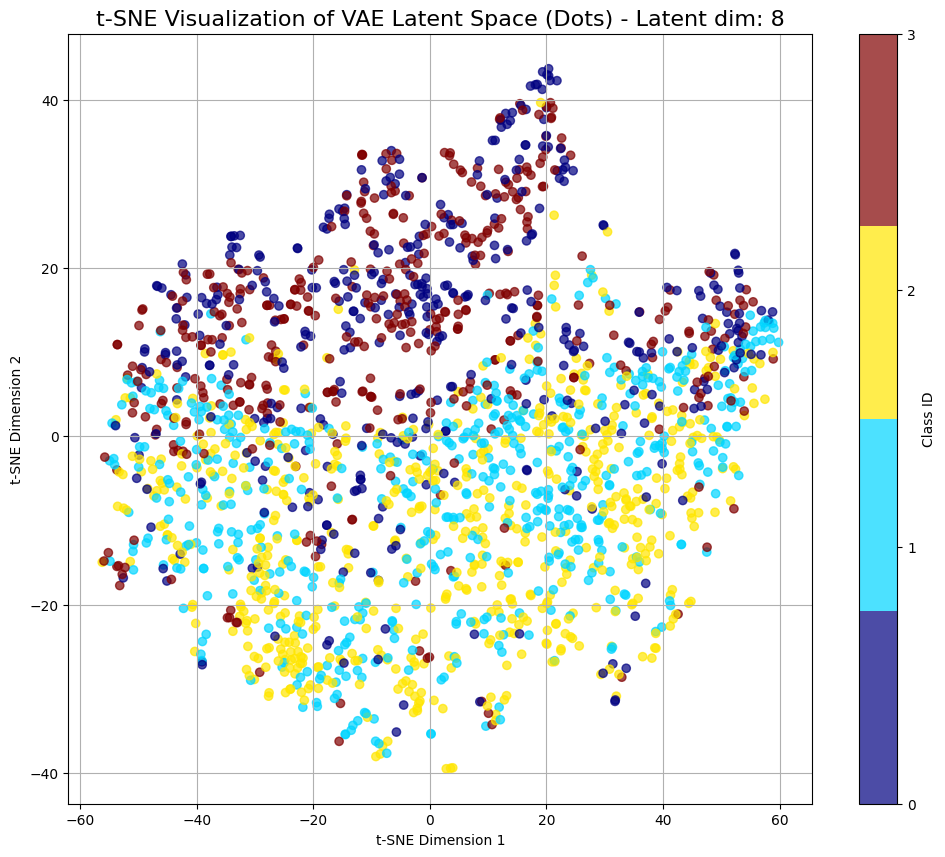

In [ ]:
import matplotlib.pyplot as plt

def plot_labeled_tsne_scatter(tsne_results, labels, latent_dim):
    """
    Creates a colored scatter plot of t-SNE results for any number of classes.
    """
    # Determine the number of classes dynamically
    num_classes = len(np.unique(labels))
    
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        c=labels, 
        # Use the dynamic number of classes for the colormap
        cmap=plt.cm.get_cmap("jet", num_classes),
        alpha=0.7
    )
    
    plt.title(f"t-SNE Visualization of VAE Latent Space (Dots) - Latent dim: {latent_dim}", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # Use the dynamic number of classes for the color bar
    cbar = plt.colorbar(scatter, ticks=range(num_classes))
    cbar.set_label("Class ID")
    
    plt.grid(True)
    plt.show()

# Call the function with your new data and the latent_dim you used
# Assuming your encoder's latent dimension is 32
plot_labeled_tsne_scatter(tsne_results, test_labels_np, latent_dim)

### Save model

In [ ]:
import os

# Create a directory to save the models
model_dir = "../../models/vae/"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the encoder and decoder models
encoder.save(os.path.join(model_dir, "m1_encoder_mitosis.keras"))
decoder.save(os.path.join(model_dir, "m1_decoder_mitosis.keras"))

print(f"Encoder and Decoder models saved to the '{model_dir}' directory.")

Encoder and Decoder models saved to the '../../models/vae/' directory.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the latent vector."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Loading models...
Models loaded successfully.
Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


2025-09-15 20:53:55.911929: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Displaying results...


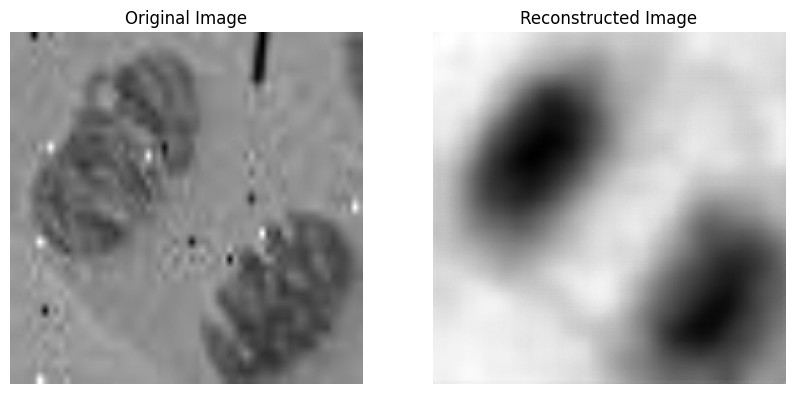

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration ---
IMAGE_PATH = "8c0932b8bf258c2ab2b24375e2357521_1.png"

IMAGE_SIZE = (200, 200)  # Must match the input shape your encoder was trained on

# --- 2. Load the Trained Models ---
print("Loading models...")
# We must tell Keras about our custom 'Sampling' layer
custom_objects = {"Sampling": Sampling}
encoder = tf.keras.models.load_model("../../models/vae/m1_encoder_mitosis.keras", custom_objects=custom_objects)
decoder = tf.keras.models.load_model("../../models/vae/m1_decoder_mitosis.keras")
print("Models loaded successfully.")

# --- 3. Load and Preprocess the Single Image ---
# Load the image file
img_raw = tf.io.read_file(IMAGE_PATH)
# Decode as 1-channel grayscale
img = tf.image.decode_image(img_raw, channels=1, expand_animations=False)
# Resize to the model's expected input size
img_resized = tf.image.resize(img, IMAGE_SIZE)
# Normalize to float32 in the [0, 1] range
img_normalized = tf.cast(img_resized, tf.float32) / 255.0
# Add the batch dimension (shape goes from (200, 200, 1) to (1, 200, 200, 1))
input_batch = tf.expand_dims(img_normalized, axis=0)

# --- 4. Run the Encoder-Decoder Pipeline ---
print("Running prediction...")
# Pass the preprocessed image batch to the encoder
# It outputs the three latent components
z_mean, z_log_var, z_sampled = encoder.predict(input_batch)

# Pass ONLY the sampled vector (z) to the decoder
reconstructed_batch = decoder.predict(z_sampled)

# Get the first (and only) image from the batch
reconstructed_image = reconstructed_batch[0]

# --- 5. Plot the Results ---
print("Displaying results...")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the Original (preprocessed) image
axes[0].imshow(img_normalized.numpy().squeeze(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

# Plot the Reconstructed image
axes[1].imshow(reconstructed_image.squeeze(), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

plt.show()

In [13]:
def define_prompt(path):
    PROPHASE_PROMPT = "allium cepa root tip cell in prophase state"
    METAPHASE_PROMPT = "allium cepa root tip cell in metaphase state"
    ANAPHASE_PROMPT = "allium cepa root tip cell in anaphase state"
    TELOPHASE_PROMPT = "allium cepa root tip cell in telophase state"
    if 'prophase' in path:
        return PROPHASE_PROMPT
    elif 'metaphase' in path:
        return METAPHASE_PROMPT
    elif 'anaphase' in path:
        return ANAPHASE_PROMPT
    elif 'telophase' in path:
        return TELOPHASE_PROMPT

In [14]:
import tensorflow as tf
import numpy as np
import os
import json
from PIL import Image
import cv2 # For high-quality resizing
import glob

# Assume 'Sampling' is defined elsewhere, if it's a custom layer for your encoder.
# If your encoder model doesn't use it or it's implicitly handled, you might remove this.
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- Configuration ---
# Update these paths to match your project structure
VAE_ENCODER_PATH = "../../models/vae/m1_encoder_mitosis_canny.keras"
VAE_DECODER_PATH = "../../models/vae/m1_decoder_mitosis_canny.keras"
ORIGINAL_IMAGES_DIR = "original_sharp_cells" # Directory containing your original images
CONTROLNET_DATASET_ROOT = "../../media/controlnet_dataset" # Output directory for ControlNet data

IMAGE_SIZE_VAE_INPUT = (200, 200) # Your VAE's expected input resolution
TARGET_RESOLUTION_CONTROLNET = 512 # Target resolution for ControlNet training

GENERIC_PROMPT = "a micrograph of an allium cepa root tip mitotic cell"

IMAGES_UNLABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/d"
IMAGES_LABELED_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification/test_v2"

unlabeled_files = glob.glob(os.path.join(IMAGES_UNLABELED_PATH, '*'))
labeled_files = glob.glob(os.path.join(IMAGES_LABELED_PATH, '*/*'))
all_files = unlabeled_files + labeled_files
# all_files = labeled_files

# --- Functions ---

def load_vae_models(encoder_path, decoder_path):
    """Loads the pre-trained Keras VAE encoder and decoder models."""
    print("Loading VAE models...")
    # We must tell Keras about our custom 'Sampling' layer if the encoder uses it
    custom_objects = {"Sampling": Sampling}
    encoder = tf.keras.models.load_model(encoder_path, custom_objects=custom_objects)
    decoder = tf.keras.models.load_model(decoder_path)
    print("VAE models loaded successfully.")
    return encoder, decoder

def preprocess_image_for_vae(image_path, target_size):
    """Loads and preprocesses a single image for VAE input."""
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_image(img_raw, channels=1, expand_animations=False) # Decode as 1-channel grayscale
    img_resized = tf.image.resize(img, target_size)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    return tf.expand_dims(img_normalized, axis=0) # Add batch dimension

def generate_vae_reconstruction(encoder_model, decoder_model, input_batch):
    """Runs the encoder-decoder pipeline to get the VAE reconstruction."""
    z_mean, z_log_var, z_sampled = encoder_model.predict(input_batch, verbose=0)
    reconstructed_batch = decoder_model.predict(z_sampled, verbose=0)
    return reconstructed_batch[0] # Get the single image from batch

def resize_image_cv2(image_array, target_size, interpolation=cv2.INTER_LANCZOS4):
    """Resizes a grayscale image using OpenCV for better quality upscaling."""
    # Ensure image_array is 2D for grayscale processing, then add back channel
    if image_array.ndim == 3 and image_array.shape[-1] == 1:
        image_array = image_array.squeeze(-1) # Remove channel dim for cv2 resize
    resized_img = cv2.resize(image_array, target_size, interpolation=interpolation)
    return np.expand_dims(resized_img, axis=-1) # Add channel dim back

def save_image_grayscale(image_array, output_path):
    """Saves a grayscale (0-1 float) NumPy image array to a file."""
    # Convert float [0,1] to uint8 [0,255]
    img_uint8 = (image_array.squeeze() * 255).astype(np.uint8)
    Image.fromarray(img_uint8, mode='L').save(output_path)

def create_controlnet_dataset(
    all_original_image_paths,
    encoder_model,
    decoder_model,
    vae_input_size,
    target_resolution_controlnet,
    controlnet_dataset_root,
    generic_prompt
):
    """
    Main function to generate VAE reconstructions, upscale, and prepare the ControlNet dataset.
    """
    print(f"\n--- Starting Data Generation for ControlNet (Total Images: {len(all_original_image_paths)}) ---")

    # Create output directories
    sharp_upscaled_dir = os.path.join(controlnet_dataset_root, "sharp_upscaled")
    blurred_upscaled_dir = os.path.join(controlnet_dataset_root, "blurred_upscaled")
    os.makedirs(sharp_upscaled_dir, exist_ok=True)
    os.makedirs(blurred_upscaled_dir, exist_ok=True)

    metadata_list = []

    for i, original_image_path in enumerate(all_original_image_paths):
        # print(f"Processing image {i+1}/{len(all_original_image_paths)}: {original_image_path}")

        # --- 1. Load and Preprocess Original Image for VAE ---
        input_batch = preprocess_image_for_vae(original_image_path, vae_input_size)
        original_img_normalized_np = input_batch[0].numpy() # Get the 0-1 normalized numpy array

        # --- 2. Generate Blurred Image from VAE ---
        reconstructed_image_np = generate_vae_reconstruction(encoder_model, decoder_model, input_batch)

        # --- 3. Upscale Both Images to Target Resolution ---
        base_name = os.path.splitext(os.path.basename(original_image_path))[0]
        sharp_upscaled_filename = f"{base_name}_sharp_{target_resolution_controlnet}x{target_resolution_controlnet}.png"
        blurred_upscaled_filename = f"{base_name}_blurred_{target_resolution_controlnet}x{target_resolution_controlnet}.png"

        sharp_upscaled_path_full = os.path.join(sharp_upscaled_dir, sharp_upscaled_filename)
        blurred_upscaled_path_full = os.path.join(blurred_upscaled_dir, blurred_upscaled_filename)

        # Upscale original sharp image
        upscaled_sharp_np = resize_image_cv2(original_img_normalized_np,
                                              (target_resolution_controlnet, target_resolution_controlnet),
                                              interpolation=cv2.INTER_LANCZOS4)
        save_image_grayscale(upscaled_sharp_np, sharp_upscaled_path_full)

        # Upscale VAE blurred image
        upscaled_blurred_np = resize_image_cv2(reconstructed_image_np,
                                               (target_resolution_controlnet, target_resolution_controlnet),
                                               interpolation=cv2.INTER_LANCZOS4)
        save_image_grayscale(upscaled_blurred_np, blurred_upscaled_path_full)


        # --- 4. Add to Metadata ---
        metadata_list.append({
            "file_name": os.path.join("sharp_upscaled", sharp_upscaled_filename),
            "conditioning_image": os.path.join("blurred_upscaled", blurred_upscaled_filename),
            "text": define_prompt(original_image_path) or generic_prompt
        })

    # Save metadata.jsonl
    metadata_path = os.path.join(controlnet_dataset_root, "metadata.jsonl")
    with open(metadata_path, "w") as f:
        for item in metadata_list:
            f.write(json.dumps(item) + "\n")

    print(f"\n--- Data generation complete. Metadata saved to {metadata_path} ---")
    print(f"ControlNet dataset prepared in: {controlnet_dataset_root}")

# --- Your actual list of original image paths ---
# Assuming all your original images are in ORIGINAL_IMAGES_DIR
all_original_image_paths = all_files
# [
#     os.path.join(ORIGINAL_IMAGES_DIR, f)
#     for f in os.listdir(ORIGINAL_IMAGES_DIR)
#     if f.lower().endswith(('.png', '.jpg', '.jpeg'))
# ]
# If your list is already populated from elsewhere, just assign it:
# all_original_image_paths = YOUR_PREPOPULATED_LIST_OF_PATHS

if not all_original_image_paths:
    print(f"ERROR: No images found in {ORIGINAL_IMAGES_DIR} or your image list is empty.")
    print("Please ensure your 'all_original_image_paths' list is correctly populated.")
else:
    # Load VAE models
    # Ensure the VAE_ENCODER_PATH and VAE_DECODER_PATH are correct relative to where you run this script.
    encoder, decoder = load_vae_models(VAE_ENCODER_PATH, VAE_DECODER_PATH)

    # Run the dataset creation
    create_controlnet_dataset(
        all_original_image_paths,
        encoder,
        decoder,
        IMAGE_SIZE_VAE_INPUT,
        TARGET_RESOLUTION_CONTROLNET,
        CONTROLNET_DATASET_ROOT,
        GENERIC_PROMPT
    )

Loading VAE models...
VAE models loaded successfully.

--- Starting Data Generation for ControlNet (Total Images: 3509) ---


2025-09-17 23:09:08.091379: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-09-17 23:09:08.167645: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
2025-09-17 23:09:13.102187: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=Map


--- Data generation complete. Metadata saved to ../../media/controlnet_dataset/metadata.jsonl ---
ControlNet dataset prepared in: ../../media/controlnet_dataset
